# M7: Monte Carlo Cash Flow Simulation
**Hybrid Pelvic Health PT + Pilates Studio**

Group 6 | BU.152.710 Entrepreneurial Ventures | Spring 2026

This notebook runs a 10,000-trial Monte Carlo simulation of the venture's first 36 months of operating cash flow.

**What it does:**
1. Holds the deterministic structure of the financial model fixed (pricing, hiring schedule, capex)
2. Treats 10 key business drivers as random variables, each drawn from a realistic distribution
3. Computes summary statistics and percentile bands
4. Generates 5 visualizations (cumulative cash fan chart, breakeven histogram, capital CDF, M36 distributions, joint scatter)

**Outputs:**
- `mc_stats.json` — summary statistics
- `mc_chart_1_fan.png` through `mc_chart_5_joint.png` — visualizations

## 1. Imports and config

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# Where to save outputs (charts + stats JSON)
OUT = "."  # current directory; change to absolute path if desired
os.makedirs(OUT, exist_ok=True)

# Reproducibility — same seed = same results every time
np.random.seed(42)

# Simulation size
N_TRIALS = 10_000
N_MONTHS = 36

print(f"Running {N_TRIALS:,} trials over {N_MONTHS} months")

Running 10,000 trials over 36 months


## 2. Deterministic inputs (fixed)

**Pricing** — anchored to Group 6 (2026) primary research survey (n=54):
- $129 monthly membership: midpoint of $100–150 'great deal' band identified by 74% of respondents
- $75 single session: per-session WTP ceiling 80% of respondents accepted
- $29 app-only: priced below MUTU System and Bloom Method
- $199 premium 'Active Aging' tier: 41+ outliers indicated WTP $200+
- $25 PEPM: low end of Hinge Health-cited digital MSK band

**Pre-opening capex** of $230K (10 reformers, buildout, brand launch, SW setup, legal, pre-opening payroll, working capital buffer).

In [2]:
# Pricing (USD)
PRICE = {
    'membership':        129,   # $/month
    'session':            75,   # $/session
    'app':                29,   # $/month
    'premium_upcharge':   70,   # $/month above base membership
    'pepm':               25    # $/employee/month for B2B contracts
}

# Pre-opening capex — sunk at Month 0
STARTUP_CAPEX = 230_000

PRICE

{'membership': 129,
 'session': 75,
 'app': 29,
 'premium_upcharge': 70,
 'pepm': 25}

## 3. Baseline volume curves (deterministic)

- These are the planned ramps for each revenue stream. 
- Each Monte Carlo trial multiplies these by a random factor to capture the realistic variance around plan.

In [3]:
def baseline_members(m):
    """Active members at end of month m.
    Y1: 25 → 179 at +14/month; Y2: → 395 at +18/month; Y3: → 539 at +12/month."""
    if m <= 0:  return 0
    if m <= 12: return 25  + (m - 1)  * 14
    if m <= 24: return 179 + (m - 12) * 18
    return            395 + (m - 24) * 12

def baseline_sessions(m):
    """Drop-in single sessions per month."""
    if m <= 0:  return 0
    if m <= 12: return 30  + (m - 1)  * 6
    if m <= 24: return 96  + (m - 12) * 4
    return            144 + (m - 24) * 2

def baseline_app(m):
    """App-only subscribers (digital channel launches M3)."""
    if m <= 2:  return 0
    if m <= 12: return (m - 2) * 12
    if m <= 24: return 120 + (m - 12) * 10
    return            240 + (m - 24) * 8

# Quick sanity check
print(f"Members:  M1={baseline_members(1)}, M12={baseline_members(12)}, M24={baseline_members(24)}, M36={baseline_members(36)}")
print(f"Sessions: M1={baseline_sessions(1)}, M12={baseline_sessions(12)}, M24={baseline_sessions(24)}, M36={baseline_sessions(36)}")
print(f"App:      M3={baseline_app(3)}, M12={baseline_app(12)}, M24={baseline_app(24)}, M36={baseline_app(36)}")

Members:  M1=25, M12=179, M24=395, M36=539
Sessions: M1=30, M12=96, M24=144, M36=168
App:      M3=12, M12=120, M24=240, M36=336


## 4. Operating cost schedule

Fixed monthly operating costs grows over time as we add staff. 
Wage multipliers `pt_w` and `pil_w` are passed in by the simulation to capture wage inflation uncertainty.

Sources:
- Rent: cityfeet.com Parker CO medical office lease comp ($35/sf/yr × 1,500 sf)
- PT salary: Indeed Parker CO ($51.35/hr × 173 hrs × 1.25 benefits)
- Pilates instructor: Indeed Colorado ($39.30/hr × 173 × 1.25)
- Admin: Indeed Parker CO ($21.05/hr × 173 × 1.25)
- Software: PtEverywhere all-in-one
- Insurance: The Hartford
- Utilities: Finmodelslab physiotherapy clinic benchmark

In [15]:
def baseline_opex(m, pt_w=1.0, pil_w=1.0):
    """Monthly fixed operating cost (excl COGS) at month m.
    pt_w, pil_w are wage multipliers applied to PT and Pilates instructor salaries."""
    cost = 0
    cost += 4375                  # rent
    cost += 4560                  # admin
    cost += 199                   # software base
    cost += 100                   # insurance
    cost += 1200                  # utilities + cleaning
    cost += 2000                  # misc / professional fees

    # Always-on clinical staff
    cost += 11125 * pt_w          # Pelvic PT 1
    cost += 8515  * pil_w         # Pilates Instructor 1

    # Marketing — ramps over time
    if   1 <= m < 7:  cost += 5000
    elif 7 <= m < 13: cost += 7500
    else:             cost += 10000

    # Hiring schedule
    if m >= 6:  cost += 8515  * pil_w  # Pilates Instructor 2
    if m >= 9:  cost += 11125 * pt_w   # Pelvic PT 2
    if m >= 12: cost += 5500           # Community / marketing manager
    if m >= 15: cost += 50             # Extra software seat (>11 PTs threshold)
    if m >= 18: cost += 6500           # Founder draw begins
    if m >= 24: cost += 11125 * pt_w   # Pelvic PT 3

    return cost

# Sanity check
print(f"Opex M1: ${baseline_opex(1):>8,.0f}")
print(f"Opex M12: ${baseline_opex(12):>7,.0f}")
print(f"Opex M24: ${baseline_opex(24):>7,.0f}")

Opex M1: $  37,074
Opex M12: $ 64,714
Opex M24: $ 84,889


## 5. One trial (dry run)
**The 10 stochastic drivers:**

| Driver | Distribution | Rationale |
|---|---|---|
| Member growth multiplier | Normal(1.0, σ=0.20), clipped [0.4, 1.6] | ±20% std dev around the planned ramp |
| Single-session multiplier | Normal(1.0, σ=0.20), clipped [0.4, 1.6] | Independent of membership |
| App-only multiplier | Normal(1.0, σ=0.30), clipped [0.0, 2.0] | Highest variance — least proven channel |
| First B2B contract month | DiscreteUniform[7, 12] | Sales-cycle reality is ±3 months around plan |
| First B2B contract size | Triangular(100, 200, 400) | Small-employer pilot range |
| Second B2B contract month | DiscreteUniform[15, 22] | Second contract ~9 months after first |
| Second B2B contract size | Triangular(300, 500, 800) | Mid-market employer |
| Pelvic PT wage multiplier | Normal(1.0, σ=0.08), floor 0.85 | APTA-flagged supply constraint |
| Pilates wage multiplier | Normal(1.0, σ=0.06), floor 0.85 | Less constrained labor market |
| COGS as % of revenue | Normal(0.06, σ=0.015), floor 0.02 | Adjusted from Finmodelslab benchmark |

In [16]:
def run_trial():
    """Run one 36-month simulation. Returns (cumulative cash array, M36 revenue path,
    M36 EBITDA path, breakeven month)."""

    # ---- Sample stochastic inputs ----
    members_mult  = np.clip(np.random.normal(1.0, 0.20), 0.4, 1.6)
    sessions_mult = np.clip(np.random.normal(1.0, 0.20), 0.4, 1.6)
    app_mult      = np.clip(np.random.normal(1.0, 0.30), 0.0, 2.0)

    b2b1_month    = np.random.randint(7, 13)              # M7–M12 inclusive
    b2b1_size     = int(np.random.triangular(100, 200, 400))
    b2b2_month    = np.random.randint(15, 23)             # M15–M22 inclusive
    b2b2_addsize  = int(np.random.triangular(300, 500, 800))

    pt_w  = max(0.85, np.random.normal(1.0, 0.08))
    pil_w = max(0.85, np.random.normal(1.0, 0.06))
    cogs_pct = max(0.02, np.random.normal(0.06, 0.015))

    # ---- Walk the 36 months ----
    cum_cash    = np.zeros(N_MONTHS + 1)
    rev_path    = np.zeros(N_MONTHS + 1)
    ebitda_path = np.zeros(N_MONTHS + 1)

    cum_cash[0] = -STARTUP_CAPEX  # capex hits at M0; no financing modeled (operating-only)
    breakeven = -1                 # -1 = not yet reached

    for m in range(1, N_MONTHS + 1):
        # Volumes
        members  = baseline_members(m)  * members_mult
        sessions = baseline_sessions(m) * sessions_mult
        app      = baseline_app(m)      * app_mult
        premium  = members * 0.08      # 8% upgrade rate

        b2b_ee = (b2b1_size if m >= b2b1_month else 0) \
               + (b2b2_addsize if m >= b2b2_month else 0)

        # Revenue
        rev = (members  * PRICE['membership']
             + sessions * PRICE['session']
             + app      * PRICE['app']
             + premium  * PRICE['premium_upcharge']
             + b2b_ee   * PRICE['pepm'])

        # Cost
        cogs = rev * cogs_pct
        opex = baseline_opex(m, pt_w, pil_w)

        # P&L
        ebitda = rev - cogs - opex

        # Cash position
        cum_cash[m]    = cum_cash[m-1] + ebitda
        rev_path[m]    = rev
        ebitda_path[m] = ebitda

        # First profitable month
        if breakeven == -1 and ebitda > 0:
            breakeven = m

    return cum_cash, rev_path, ebitda_path, breakeven

# Test one trial
cum, rev, eb, be = run_trial()
print(f"Sample trial — breakeven month: M{be}")
print(f"               peak burn:       ${cum.min():,.0f}")
print(f"               M36 cum cash:    ${cum[-1]:,.0f}")

Sample trial — breakeven month: M20
               peak burn:       $-642,789
               M36 cum cash:    $-441,282


## 6. Expand Model (run 10,000 reps)

In [6]:
# Pre-allocate arrays for performance
all_cum    = np.zeros((N_TRIALS, N_MONTHS + 1))
all_rev    = np.zeros((N_TRIALS, N_MONTHS + 1))
all_eb     = np.zeros((N_TRIALS, N_MONTHS + 1))
all_be     = np.zeros(N_TRIALS, dtype=int)

# Reset seed so the run is fully reproducible from this cell forward
np.random.seed(42)

for i in range(N_TRIALS):
    c, r, e, b = run_trial()
    all_cum[i] = c
    all_rev[i] = r
    all_eb[i]  = e
    all_be[i]  = b

print(f"Done. Ran {N_TRIALS:,} trials.")

Done. Ran 10,000 trials.


## 7. Compute summary stats

- For each month, compute the P5/P10/P25/P50/P75/P90/P95 percentile across all trials. 
- Compute distributions of breakeven month, peak cash burn, and M36 outcomes.

In [7]:
# Per-month percentiles of cumulative cash (and revenue)
pct_cum = np.percentile(all_cum, [5, 10, 25, 50, 75, 90, 95], axis=0)
pct_rev = np.percentile(all_rev, [5, 10, 25, 50, 75, 90, 95], axis=0)

# Per-trial outcomes
peak_burn       = np.min(all_cum, axis=1)        # most-negative cumulative cash
capital_needed  = np.abs(peak_burn)               # what we'd need to raise
be_achieved     = all_be[all_be > 0]              # only trials that hit breakeven
prob_be         = np.mean(all_be > 0)             # probability of reaching breakeven by M36

# Build a stats dict for export
stats = {
    "n_trials": N_TRIALS,
    "n_months": N_MONTHS,
    "prob_breakeven_by_M36": float(prob_be),
    "be_p10": int(np.percentile(be_achieved, 10)),
    "be_p25": int(np.percentile(be_achieved, 25)),
    "be_p50": int(np.percentile(be_achieved, 50)),
    "be_p75": int(np.percentile(be_achieved, 75)),
    "be_p90": int(np.percentile(be_achieved, 90)),
    "capital_p10": float(np.percentile(capital_needed, 10)),
    "capital_p25": float(np.percentile(capital_needed, 25)),
    "capital_p50": float(np.percentile(capital_needed, 50)),
    "capital_p75": float(np.percentile(capital_needed, 75)),
    "capital_p90": float(np.percentile(capital_needed, 90)),
    "capital_p95": float(np.percentile(capital_needed, 95)),
    "rev_m36_p10": float(np.percentile(all_rev[:, 36], 10)),
    "rev_m36_p50": float(np.percentile(all_rev[:, 36], 50)),
    "rev_m36_p90": float(np.percentile(all_rev[:, 36], 90)),
    "ebitda_m36_p10": float(np.percentile(all_eb[:, 36], 10)),
    "ebitda_m36_p50": float(np.percentile(all_eb[:, 36], 50)),
    "ebitda_m36_p90": float(np.percentile(all_eb[:, 36], 90)),
}

# Save to JSON
with open(f"{OUT}/mc_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print(json.dumps(stats, indent=2))

{
  "n_trials": 10000,
  "n_months": 36,
  "prob_breakeven_by_M36": 0.9347,
  "be_p10": 17,
  "be_p25": 19,
  "be_p50": 21,
  "be_p75": 23,
  "be_p90": 32,
  "capital_p10": 561520.7040067815,
  "capital_p25": 608426.1001634952,
  "capital_p50": 675725.7958651986,
  "capital_p75": 774744.1651653142,
  "capital_p90": 901883.9436604447,
  "capital_p95": 996556.8939745027,
  "rev_m36_p10": 94540.8808265517,
  "rev_m36_p50": 114203.3958122177,
  "rev_m36_p90": 134248.12590457936,
  "ebitda_m36_p10": 3344.0765603014415,
  "ebitda_m36_p50": 22229.762996569334,
  "ebitda_m36_p90": 41601.43499365509
}


## 8. Data Viz

### Chart 1 — Cumulative cash fan chart

Shows the spread of cumulative cash across all 10,000 trials. Median is the navy line; shaded bands are P5–P95, P10–P90, P25–P75.

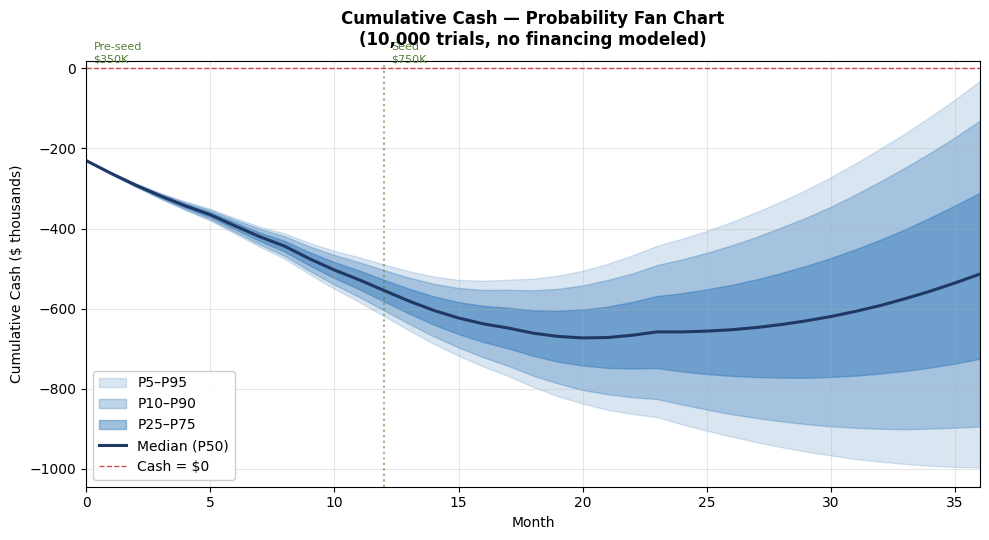

In [8]:
plt.rcParams.update({'font.size': 10, 'font.family': 'DejaVu Sans'})

fig, ax = plt.subplots(figsize=(10, 5.5))
months = np.arange(N_MONTHS + 1)

ax.fill_between(months, pct_cum[0]/1000, pct_cum[6]/1000, alpha=0.18, color='#2E75B6', label='P5–P95')
ax.fill_between(months, pct_cum[1]/1000, pct_cum[5]/1000, alpha=0.30, color='#2E75B6', label='P10–P90')
ax.fill_between(months, pct_cum[2]/1000, pct_cum[4]/1000, alpha=0.45, color='#2E75B6', label='P25–P75')
ax.plot(months, pct_cum[3]/1000, color='#1F3864', linewidth=2.2, label='Median (P50)')
ax.axhline(0, color='#C00000', linestyle='--', linewidth=1, alpha=0.7, label='Cash = $0')

ax.set_title(f'Cumulative Cash — Probability Fan Chart\n({N_TRIALS:,} trials, no financing modeled)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Cash ($ thousands)')
ax.legend(loc='lower left', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 36)

# Mark financing rounds
ax.axvline(0,  color='#548235', linestyle=':', alpha=0.6)
ax.axvline(12, color='#548235', linestyle=':', alpha=0.6)
ax.text(0.3,  ax.get_ylim()[1]*0.92, 'Pre-seed\n$350K', fontsize=8, color='#548235')
ax.text(12.3, ax.get_ylim()[1]*0.92, 'Seed\n$750K',     fontsize=8, color='#548235')

plt.tight_layout()
plt.savefig(f"{OUT}/mc_chart_1_fan.png", dpi=160, bbox_inches='tight')
plt.show()

### Chart 2 — Distribution of breakeven month

Histogram showing how often each month was the breakeven month. The bimodal pattern (two peaks, one near M21 and one near M32) reveals that the second B2B contract is the dominant driver.

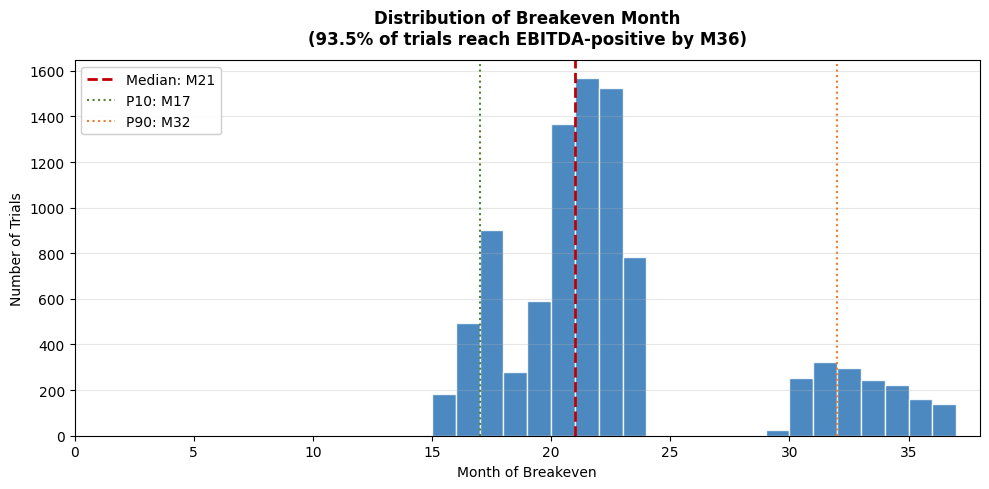

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, 38)
ax.hist(be_achieved, bins=bins, color='#2E75B6', edgecolor='white', alpha=0.85)

median_be = int(np.median(be_achieved))
p10_be    = int(np.percentile(be_achieved, 10))
p90_be    = int(np.percentile(be_achieved, 90))

ax.axvline(median_be, color='#C00000', linestyle='--', linewidth=2,   label=f'Median: M{median_be}')
ax.axvline(p10_be,    color='#548235', linestyle=':',  linewidth=1.5, label=f'P10: M{p10_be}')
ax.axvline(p90_be,    color='#ED7D31', linestyle=':',  linewidth=1.5, label=f'P90: M{p90_be}')

ax.set_title(f'Distribution of Breakeven Month\n({prob_be*100:.1f}% of trials reach EBITDA-positive by M36)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Month of Breakeven')
ax.set_ylabel('Number of Trials')
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(0, 38)

plt.tight_layout()
plt.savefig(f"{OUT}/mc_chart_2_be.png", dpi=160, bbox_inches='tight')
plt.show()

### Chart 3 — Cumulative distribution of total capital required

Read as: "There is X% probability the venture needs ≤ $Y of capital." 

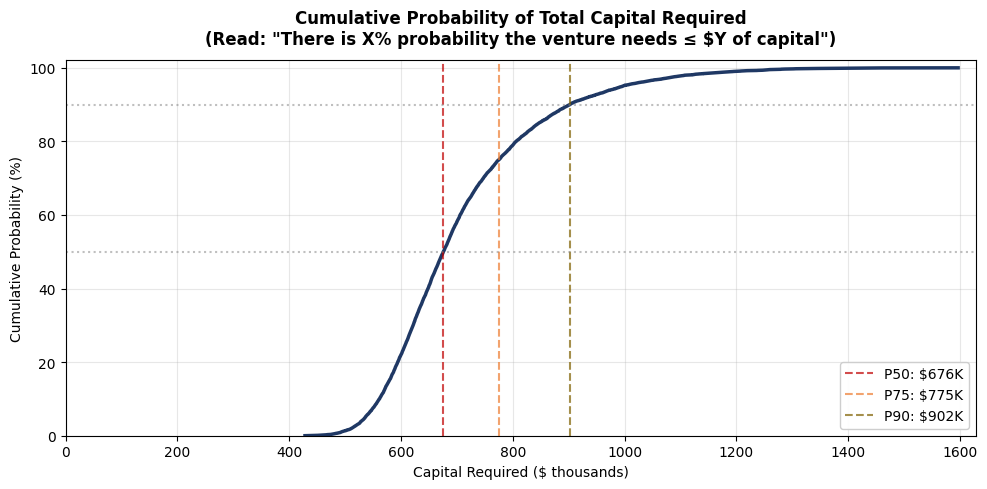

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sorted_cap = np.sort(capital_needed) / 1000
cdf_vals   = np.arange(1, len(sorted_cap) + 1) / len(sorted_cap) * 100

ax.plot(sorted_cap, cdf_vals, color='#1F3864', linewidth=2.5)

for pct, color, label in [(50, '#C00000', 'P50'), (75, '#ED7D31', 'P75'), (90, '#7F6000', 'P90')]:
    val = np.percentile(capital_needed, pct) / 1000
    ax.axvline(val, color=color, linestyle='--', alpha=0.7, label=f'{label}: ${val:,.0f}K')

ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.axhline(90, color='gray', linestyle=':', alpha=0.5)

ax.set_title('Cumulative Probability of Total Capital Required\n(Read: "There is X% probability the venture needs ≤ $Y of capital")',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Capital Required ($ thousands)')
ax.set_ylabel('Cumulative Probability (%)')
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sorted_cap[-1] * 1.02)
ax.set_ylim(0, 102)

plt.tight_layout()
plt.savefig(f"{OUT}/mc_chart_3_capital_cdf.png", dpi=160, bbox_inches='tight')
plt.show()

### Chart 4 — M36 revenue and EBITDA distributions

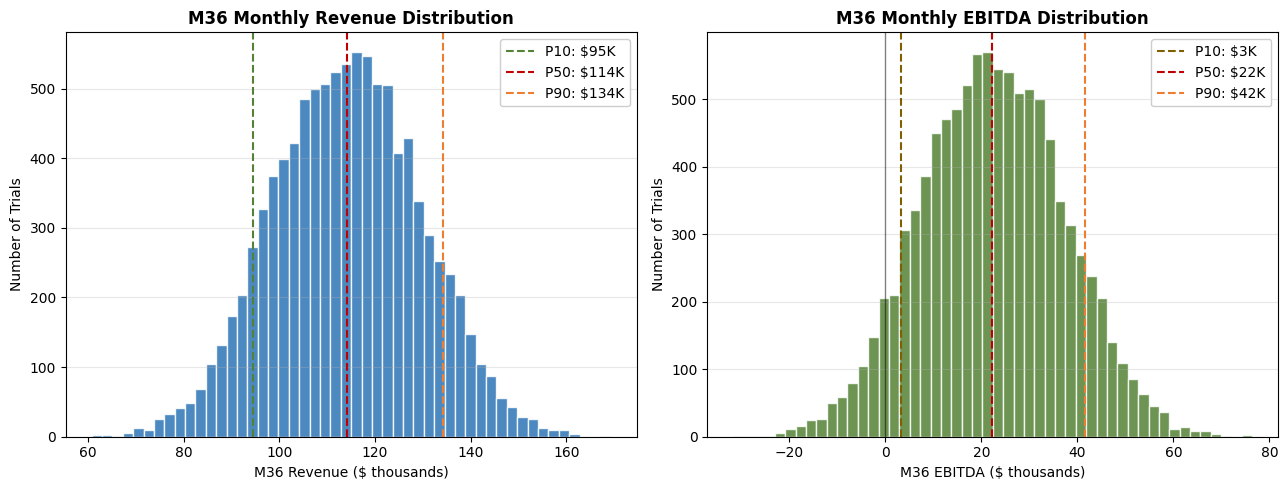

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue
ax = axes[0]
ax.hist(all_rev[:, 36] / 1000, bins=50, color='#2E75B6', edgecolor='white', alpha=0.85)
for pct, color, label in [(10, '#548235', 'P10'), (50, '#C00000', 'P50'), (90, '#ED7D31', 'P90')]:
    val = np.percentile(all_rev[:, 36], pct) / 1000
    ax.axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{label}: ${val:,.0f}K')
ax.set_title('M36 Monthly Revenue Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('M36 Revenue ($ thousands)')
ax.set_ylabel('Number of Trials')
ax.legend(framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')

# EBITDA
ax = axes[1]
ax.hist(all_eb[:, 36] / 1000, bins=50, color='#548235', edgecolor='white', alpha=0.85)
for pct, color, label in [(10, '#7F6000', 'P10'), (50, '#C00000', 'P50'), (90, '#ED7D31', 'P90')]:
    val = np.percentile(all_eb[:, 36], pct) / 1000
    ax.axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{label}: ${val:,.0f}K')
ax.axvline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax.set_title('M36 Monthly EBITDA Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('M36 EBITDA ($ thousands)')
ax.set_ylabel('Number of Trials')
ax.legend(framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{OUT}/mc_chart_4_m36.png", dpi=160, bbox_inches='tight')
plt.show()

### Chart 5 — Joint distribution of breakeven month vs. capital required

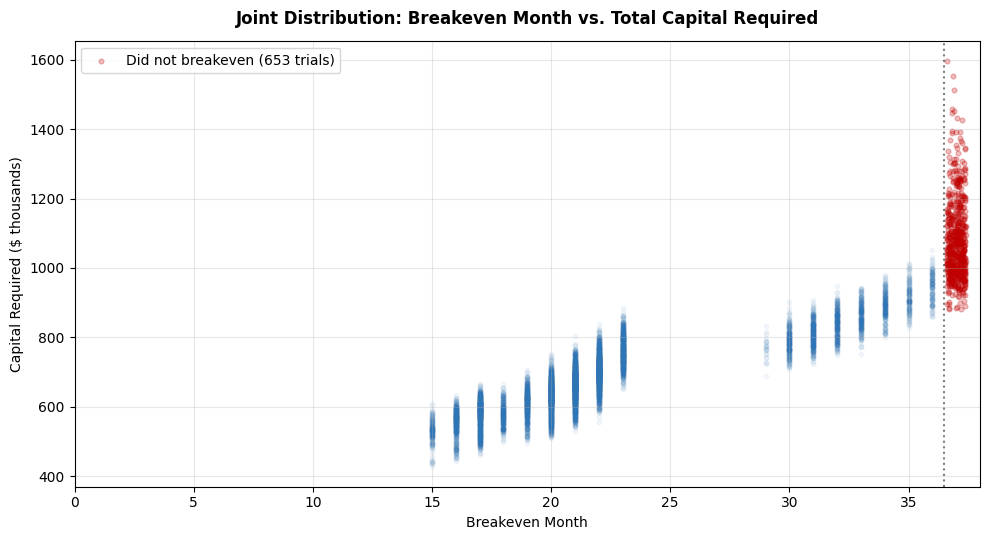

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Trials that breakeven
mask = all_be > 0
ax.scatter(all_be[mask], capital_needed[mask] / 1000,
           alpha=0.05, s=10, color='#2E75B6')

# Trials that did NOT breakeven — pin to the right edge with a small jitter
neverbe = ~mask
if neverbe.sum() > 0:
    ax.scatter(np.full(neverbe.sum(), 37) + np.random.uniform(-0.4, 0.4, neverbe.sum()),
               capital_needed[neverbe] / 1000,
               alpha=0.25, s=12, color='#C00000',
               label=f'Did not breakeven ({neverbe.sum()} trials)')

ax.axvline(36.5, color='black', linestyle=':', alpha=0.5)
ax.set_title('Joint Distribution: Breakeven Month vs. Total Capital Required',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Breakeven Month')
ax.set_ylabel('Capital Required ($ thousands)')
ax.set_xlim(0, 38)
ax.grid(True, alpha=0.3)

if neverbe.sum() > 0:
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f"{OUT}/mc_chart_5_joint.png", dpi=160, bbox_inches='tight')
plt.show()

## 9. Headline outputs

In [13]:
print("="*60)
print("MONTE CARLO HEADLINE OUTPUTS")
print("="*60)
print(f"Trials run:                    {N_TRIALS:,}")
print(f"Months simulated:              {N_MONTHS}")
print()
print(f"Probability of breakeven by M36:  {prob_be*100:.1f}%")
print(f"Median breakeven month:           M{int(np.median(be_achieved))}")
print(f"80% CI on breakeven month:        M{int(np.percentile(be_achieved, 10))}–M{int(np.percentile(be_achieved, 90))}")
print()
print(f"Median capital required:          ${np.percentile(capital_needed, 50):>10,.0f}")
print(f"80% CI on capital required:       ${np.percentile(capital_needed, 10):>10,.0f} – ${np.percentile(capital_needed, 90):,.0f}")
print(f"P95 capital required:             ${np.percentile(capital_needed, 95):>10,.0f}")
print()
print(f"M36 revenue (P10/P50/P90):        ${np.percentile(all_rev[:, 36], 10):>10,.0f} / ${np.percentile(all_rev[:, 36], 50):,.0f} / ${np.percentile(all_rev[:, 36], 90):,.0f}")
print(f"M36 EBITDA  (P10/P50/P90):        ${np.percentile(all_eb[:, 36], 10):>10,.0f} / ${np.percentile(all_eb[:, 36], 50):,.0f} / ${np.percentile(all_eb[:, 36], 90):,.0f}")
print(f"Pct trials EBITDA-positive @ M36: {np.mean(all_eb[:, 36] > 0)*100:.1f}%")

MONTE CARLO HEADLINE OUTPUTS
Trials run:                    10,000
Months simulated:              36

Probability of breakeven by M36:  93.5%
Median breakeven month:           M21
80% CI on breakeven month:        M17–M32

Median capital required:          $   675,726
80% CI on capital required:       $   561,521 – $901,884
P95 capital required:             $   996,557

M36 revenue (P10/P50/P90):        $    94,541 / $114,203 / $134,248
M36 EBITDA  (P10/P50/P90):        $     3,344 / $22,230 / $41,601
Pct trials EBITDA-positive @ M36: 93.5%


---

**Notes**

- Re-running this notebook with the same `np.random.seed(42)` will produce identical results.
- Changing the seed will produce slightly different percentile estimates due to sampling variance, but the conclusions should be stable to within a few percent.
- To run a sensitivity on a single driver, fix the others to `1.0` (or to their base values) and re-sample only the one of interest.
- To extend the projection beyond Year 3, change `N_MONTHS` to e.g. 60 — but note that the deterministic baseline curves (`baseline_members`, etc.) only have piecewise definitions through M36 and would need to be extended.
